<a href="https://colab.research.google.com/github/BigHuang-EEE/Deep-Learning/blob/main/assignment2_stat4850_spring2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Image Classification, Adversarial Robustness & PEFT

In this assignment, you will build a complete deep learning pipeline from scratch using PyTorch. You will start with a simple linear model, upgrade to a Multi-Layer Perceptron (MLP), and finally train a Convolutional Neural Network (CNN) on the CIFAR-10 dataset.

After building a strong model, you will learn how to break it. You will implement an adversarial attack to generate invisible noise that completely fools your neural network.

Finally, we will transition from vision to language. You will learn how to fine-tune a 1.1 Billion parameter Large Language Model (LLM) on a single GPU using Parameter-Efficient Fine-Tuning (PEFT).

**You will learn how to:**
* Properly format data and split datasets to avoid data leakage.
* Write a PyTorch training loop and evaluation pipeline.
* Train Linear Models, MLPs, and CNNs.
* Execute a Targeted Projected Gradient Descent (PGD) adversarial attack.
* Fine-tune an LLM using Low-Rank Adaptation (LoRA).

**Instructions for submission:**
* Please turn off AI suggestions with Edit --> Notebook settings --> Hide generative AI features.

* Please create a copy of this notebook and fill out your solutions. Please submit a link with viewing access to this notebook, as well as a pdf printout of the notebook on gradescope. (The link can be in the first cell of the pdf printout.)

* Due on March 27.


## Part 1: PyTorch Fundamentals
First, let's import the necessary libraries and download the CIFAR-10 dataset. CIFAR-10 consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 45.8MB/s]


### Task 1.1: Flattening Images

Images in PyTorch are loaded as 3D tensors (Channels, Height, Width). However, standard fully connected networks (Linear layers) expect a 1D vector as input. Before we can feed our images into a simple Linear model or MLP, we must unroll all the pixels into a single long list.

**Instructions:** Complete the method below to flatten a batch of CIFAR-10 images. Keep in mind that the first dimension of the batch (the batch size `B`) must be preserved.

In [2]:
def flatten_images(batch_images):
    """
    Args:
        batch_images: Tensor of shape (B, C, H, W)
    Returns:
        flattened_images: Tensor of shape (B, C * H * W)
    """
    # TODO: Use .view() to flatten the batch_images.
    # Keep the batch dimension (size B) as the first dimension.
    flattened = batch_images.view(batch_images.size(0), -1) # ... YOUR CODE HERE ...
    return flattened

### Task 1.2: Train / Validation Split

A golden rule of Machine Learning is that you must *never* tune your model based on the Test Set. The test set simulates unseen data in the real world. If we make decisions based on the test set, we are "cheating" (data leakage).

To properly evaluate our model during training, we need a **Validation Set**.

**Instructions:** Use `torch.utils.data.random_split` to divide `trainset_full` (which contains 50,000 images) into a `train_set` of 40,000 images and a `val_set` of 10,000 images.

torch.utils.data.Dataloader will create a dataloader from each of these datasets that loads `batch_size` number of images on each iteration.

In [3]:
from torch.utils.data import random_split

# TODO: Use random_split to create train_set and val_set
train_set, val_set = random_split(trainset_full, [40000, 10000]) # ... YOUR CODE HERE ...

trainloader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
valloader = torch.utils.data.DataLoader(val_set, batch_size=64, shuffle=False)

### Task 1.3: Define a Linear Model
Now we will define our first model: a simple Linear Classifier. This is equivalent to Logistic Regression for multiple classes. It will take the flattened image vector and output 10 scores (logits), one for each class.

**Instructions:** Define an `nn.Linear` layer that maps the flattened CIFAR-10 image size to the 10 classes. Also, define the standard loss function for multi-class classification.

In [4]:
# TODO: Define a linear layer for CIFAR-10 classification (Input size -> 10 classes)
linear_model = nn.Linear(3 * 32 * 32, 10) # ... YOUR CODE HERE ...
linear_model = linear_model.to(device)

# TODO: Define the appropriate loss function for multi-class classification
criterion = nn.CrossEntropyLoss() # ... YOUR CODE HERE ...

### Task 1.4: The Evaluation Function
To see how well our model is doing, we need to pass data through it and compare its predictions to the true labels.

Notice the `torch.no_grad()` block. During evaluation, we do not need to compute gradients because we are not updating the weights. Turning off gradients saves significant memory and compute time.

**Instructions:** Complete the evaluation function by extracting the predicted class labels from the model outputs.

In [5]:
def evaluate_error_and_loss(model, dataloader, criterion, device, flatten_inputs=False):
    model.eval() # Set the model to evaluation mode (affects dropout/batchnorm)
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad(): # Disable gradient tracking
        for data in dataloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)

            if flatten_inputs:
                images = flatten_images(images)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # TODO: Get the predicted classes from the model outputs
            # Hint: Use torch.argmax on dimension 1
            predicted = torch.argmax(outputs, dim=1) # ... YOUR CODE HERE ...

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 1 - (correct / total), total_loss / len(dataloader)

### Task 1.5: The Training Loop
The training loop is the heart of deep learning. For every batch of data, we must perform 5 core steps:
1. **Move data to device:** Send inputs and labels to the GPU (or CPU).
2. **Forward pass:** Pass the data through the model to get predictions.
3. **Zero gradients:** Clear old gradients from the previous step so they don't accumulate.
4. **Backward pass:** Calculate the gradient of the loss with respect to all model weights.
5. **Optimizer step:** Update the weights using the calculated gradients.

**Instructions:** Implement these 5 steps inside the loop.

In [6]:
def train_model(model, train_loader, val_loader, learning_rate, device=device, num_epochs=5, optimizer_type=optim.Adam, flatten_inputs=True):
    optimizer = optimizer_type(model.parameters(), lr=learning_rate)
    train_errors, val_errors = [], []

    for epoch in range(num_epochs):
        model.train() # Set the model to training mode
        for i, data in tqdm(enumerate(train_loader, 0), total=len(train_loader)):
            inputs, labels = data
            if flatten_inputs:
                inputs = flatten_images(inputs)

            # TODO 1: Move data (inputs and labels) to device
            inputs, labels = inputs.to(device), labels.to(device)

            # TODO 2: Forward pass (get outputs from the model)
            outputs = model(inputs)

            # Compute loss (Provided)
            loss = criterion(outputs, labels)

            # TODO 3: Zero the parameter gradients using the optimizer
            optimizer.zero_grad()

            # TODO 4: Backward pass (compute gradients from the loss)
            loss.backward()

            # TODO 5: Optimize (update weights using the optimizer)
            optimizer.step()

        # Evaluate on Validation set to monitor overfitting
        train_err, train_loss = evaluate_error_and_loss(model, train_loader, criterion, device, flatten_inputs)
        val_err, val_loss = evaluate_error_and_loss(model, val_loader, criterion, device, flatten_inputs)

        train_errors.append(train_err)
        val_errors.append(val_err)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Err: {train_err:.3f} | Val Err: {val_err:.3f}")

    return train_errors, val_errors

# Train the linear model
linear_errors = train_model(linear_model, trainloader, valloader, learning_rate=0.0003, flatten_inputs=True)
print(linear_errors)

100%|██████████| 625/625 [00:13<00:00, 46.53it/s]


Epoch 1/5 | Train Err: 0.602 | Val Err: 0.614


100%|██████████| 625/625 [00:11<00:00, 56.12it/s]


Epoch 2/5 | Train Err: 0.593 | Val Err: 0.610


100%|██████████| 625/625 [00:11<00:00, 56.54it/s]


Epoch 3/5 | Train Err: 0.582 | Val Err: 0.601


100%|██████████| 625/625 [00:10<00:00, 56.98it/s]


Epoch 4/5 | Train Err: 0.572 | Val Err: 0.596


100%|██████████| 625/625 [00:10<00:00, 57.79it/s]


Epoch 5/5 | Train Err: 0.577 | Val Err: 0.603
([0.601775, 0.593075, 0.582275, 0.571925, 0.57735], [0.6142000000000001, 0.6097, 0.6013, 0.5964, 0.6029])


### Task 1.6: Model Depth (MLP)

A purely linear model cannot learn complex patterns. By stacking multiple linear layers and placing a non-linear activation function (like ReLU) between them, we create a Multi-Layer Perceptron (MLP) capable of learning non-linear decision boundaries.

**Instructions:** Use `nn.Sequential` to define a Two-Layer Network. It should consist of a Linear layer, a ReLU activation, and a final Linear layer.

Notice that the `forward` method evaluates this `nn.Sequential` object, which evaluates each of these layers in turn.

In [7]:
class TwoLayerNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(TwoLayerNet, self).__init__()
        # TODO: Define the stack of layers using nn.Sequential
        # Layer 1: Linear layer (Input -> Hidden)
        # Non-linearity: ReLU
        # Layer 2: Linear layer (Hidden -> num_classes)
        self.layers = nn.Sequential(
          nn.Linear(input_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, num_classes)
        ) # ... YOUR CODE HERE ...

    def forward(self, x):
        return self.layers(x)

mlp_model = TwoLayerNet(3*32*32, 100, 10).to(device)
mlp_errors = train_model(mlp_model, trainloader, valloader, learning_rate=0.0003, flatten_inputs=True)

100%|██████████| 625/625 [00:11<00:00, 56.20it/s]


Epoch 1/5 | Train Err: 0.539 | Val Err: 0.555


100%|██████████| 625/625 [00:11<00:00, 55.98it/s]


Epoch 2/5 | Train Err: 0.500 | Val Err: 0.527


100%|██████████| 625/625 [00:10<00:00, 57.09it/s]


Epoch 3/5 | Train Err: 0.476 | Val Err: 0.513


100%|██████████| 625/625 [00:10<00:00, 59.56it/s]


Epoch 4/5 | Train Err: 0.460 | Val Err: 0.509


100%|██████████| 625/625 [00:11<00:00, 56.73it/s]


Epoch 5/5 | Train Err: 0.441 | Val Err: 0.499


## Part 2: Convolutional Neural Networks

Flattening an image destroys all spatial information. An ear of a dog might be next to its eye in the 2D image, but far away in the 1D flattened vector.

Convolutional Neural Networks (CNNs) solve this by sliding a small filter over the 2D image, preserving spatial relationships. We have provided a basic CNN architecture below. Notice that `flatten_inputs=False` when we train it!

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_model = SimpleCNN().to(device)
cnn_errors = train_model(cnn_model, trainloader, valloader, learning_rate=0.0003, flatten_inputs=False)

100%|██████████| 625/625 [00:12<00:00, 50.21it/s]


Epoch 1/5 | Train Err: 0.431 | Val Err: 0.439


100%|██████████| 625/625 [00:11<00:00, 53.50it/s]


Epoch 2/5 | Train Err: 0.358 | Val Err: 0.379


100%|██████████| 625/625 [00:11<00:00, 53.04it/s]


Epoch 3/5 | Train Err: 0.315 | Val Err: 0.346


100%|██████████| 625/625 [00:11<00:00, 52.38it/s]


Epoch 4/5 | Train Err: 0.277 | Val Err: 0.326


100%|██████████| 625/625 [00:12<00:00, 51.15it/s]


Epoch 5/5 | Train Err: 0.261 | Val Err: 0.327


### Task 2.2: Final Test Set Evaluation
Now that we have trained and tuned all of our models using the validation set, it is time to check our true performance on the unseen Test Set. We will evaluate our strongest model: the CNN.

**Instructions:** Run the cell below to see your final test error.

In [9]:
final_error, final_loss = evaluate_error_and_loss(cnn_model, testloader, criterion, device, flatten_inputs=False)
print(f'Final Test Error: {final_error*100:.2f}%')
print(f'Final Test Loss:  {final_loss:.4f}')

Final Test Error: 32.45%
Final Test Loss:  0.9268


## Part 3: Make Pigs Fly with Adversarial Examples

Neural networks can be surprisingly brittle. A model might seem incredibly accurate until it faces **Adversarial Noise**: a tiny, invisible amount of carefully calculated noise designed to completely trick the CNN into predicting the wrong class.

To truly demonstrate this, we will use a highly capable, pre-trained `ResNet50` model trained on 1,000 ImageNet categories. We will take an image of a pig, and attempt to fool this powerful model.

To prove the model isn't just failing because the image is getting noisy, we will compare **Random Noise** to **Adversarial Noise (PGD)**.

In [10]:
import torchvision.models as models
import requests
from PIL import Image
import io

# Load pre-trained ResNet50 and set to evaluation mode
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device)
resnet_model.eval()

# Load the 1000 ImageNet class labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = requests.get(url).text.split("\n")

# Model wrapper to handle ImageNet normalization internally.
# This allows us to perturb the raw pixel values directly!
class NormalizedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.model(x)

norm_model = NormalizedModel(resnet_model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


### Task 3.1: Prepare the Target Image
Run the code below to download our target image and see what ResNet classifies it as out-of-the-box.

In [11]:
# Download an image of a pig
pig_url = "https://www.worldanimalprotection.us/cdn-cgi/image/width=2304,format=auto/siteassets/images/farming/pigs/pig-in-field-getty.png"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
response = requests.get(pig_url, headers=headers)
# Ensure image is converted to RGB (3 channels) to avoid Alpha channels or Grayscale issues
pig_img = Image.open(io.BytesIO(response.content)).convert('RGB')

# Preprocess to ResNet's expected size (224x224 pixels in the range [0, 1])
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

pig_tensor = preprocess(pig_img).unsqueeze(0).to(device)

# Get Original Prediction
with torch.no_grad():
    output = norm_model(pig_tensor)
    _, predicted_idx = torch.max(output, 1)
    original_label_idx = predicted_idx.item()
    print(f"Original Classification: {imagenet_classes[original_label_idx]}")

Original Classification: hog


### Task 3.2: Generating Random vs Adversarial Noise
We will use the **Projected Gradient Descent (PGD)** Method. Normally during training, we calculate the gradient of the loss with respect to the *weights*. For an adversarial attack, we calculate the gradient of the loss with respect to the *input image*! We then adjust the image pixels iteratively in the direction that minimizes the loss for a specific "target" class, making the model confident but wrong.

In [12]:
def targeted_pgd_attack(model, input_img, target_label, epsilon, alpha=0.01, num_iter=20):
    """
    Projected Gradient Descent (PGD) Targeted Attack
    Args:
        alpha: Step size for each iteration
        num_iter: Number of iterations
    """
    # Start with a copy of the image
    x_adv = input_img.clone().detach().to(device)

    for i in range(num_iter):
        x_adv.requires_grad = True

        outputs = model(x_adv)
        criterion = nn.CrossEntropyLoss()
        loss = criterion(outputs, target_label)

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            # TODO 1: Update: Move towards the target (minimize loss)
            # Hint: We SUBTRACT the gradient because we want to minimize the loss for the target class
            x_adv = x_adv - alpha * x_adv.grad.sign()

            # TODO 2: Projection Step (L-infinity norm)
            # Hint: Clip the perturbation (x_adv - input_img) to be within [-epsilon, +epsilon]
            # Then add the perturbation back to input_img
            perturbation = torch.clamp(x_adv - input_img, min=-epsilon, max=epsilon)
            x_adv = input_img + perturbation

            # TODO 3: Valid Image Step
            # Hint: Ensure pixel values are still in [0, 1] using torch.clamp
            x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach()

epsilon = 0.05 # Lower epsilon is often sufficient for PGD

# Find the index for 'airliner'
target_class_name = 'airliner'
target_idx = [i for i, c in enumerate(imagenet_classes) if target_class_name in c][0]
print(f"Targeting Class: {imagenet_classes[target_idx]} (ID: {target_idx})")

target_label_tensor = torch.tensor([target_idx]).to(device)

# 1. Generate Targeted Adversarial Image using PGD
adv_pig_tensor = targeted_pgd_attack(norm_model, pig_tensor, target_label_tensor, epsilon)

# 2. Generate Random Noise Image (for comparison)
# TODO: Create random noise of the same shape as pig_tensor.
# Hint: Use torch.rand_like(pig_tensor) * 2 - 1 to get noise uniformly distributed between -1 and 1.
# Take the torch.sign() of this noise, multiply by epsilon, and add it to pig_tensor.
# Finally, use torch.clamp to ensure it stays between 0 and 1.
random_noise = torch.sign(torch.rand_like(pig_tensor) * 2 - 1) * epsilon
random_pig_tensor = torch.clamp(pig_tensor + random_noise, 0, 1)

Targeting Class: airliner (ID: 404)


### Task 3.3: Visualize the Trickery
Run the cell below to plot all three images side-by-side. Notice how to the human eye, both noisy images look practically identical.

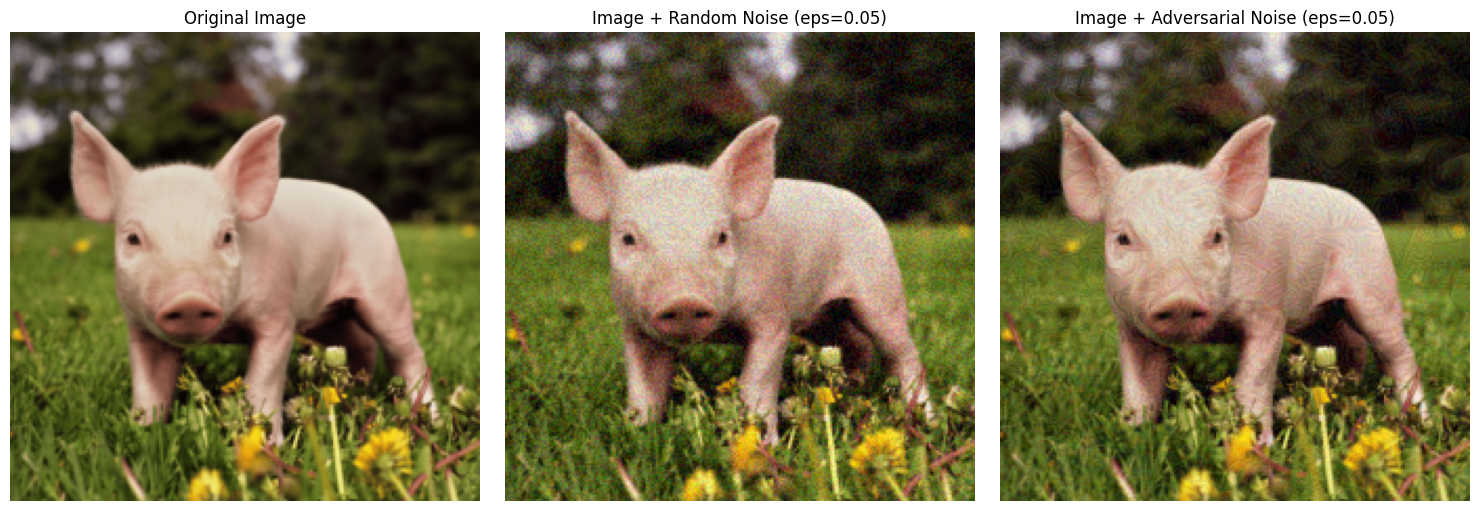

In [13]:
def tensor_to_img(t):
    # Convert tensor back to a format suitable for matplotlib plotting
    return t.squeeze(0).cpu().detach().permute(1, 2, 0).numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(tensor_to_img(pig_tensor))
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(tensor_to_img(random_pig_tensor))
ax[1].set_title(f"Image + Random Noise (eps={epsilon})")
ax[1].axis('off')

ax[2].imshow(tensor_to_img(adv_pig_tensor))
ax[2].set_title(f"Image + Adversarial Noise (eps={epsilon})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Task 3.4: Evaluate the Attack
We have established the images look identical to humans. Now let's see what the ResNet model thinks.

In [15]:
def predict_and_print(name, img_tensor):
    with torch.no_grad():
        output = norm_model(img_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        score, predicted_idx = torch.max(probs, 1)
        print(f"{name:25s} -> Predicted: {imagenet_classes[predicted_idx.item()]:20s} (Confidence: {score.item():.2%})")

print("--- Model Predictions ---")
predict_and_print("Original Image", pig_tensor)
predict_and_print("Random Noise Image", random_pig_tensor)

# TODO: Call predict_and_print for the adversarial image
predict_and_print("Adversarial Image", adv_pig_tensor) # ... YOUR CODE HERE ...

--- Model Predictions ---
Original Image            -> Predicted: hog                  (Confidence: 51.10%)
Random Noise Image        -> Predicted: hog                  (Confidence: 43.88%)
Adversarial Image         -> Predicted: airliner             (Confidence: 99.99%)


## Part 4: Behavioral Steering with LoRA (Making the Model Happy!)

While we trained our CNN from scratch, doing so for a Large Language Model (LLM) with billions of parameters is incredibly expensive. Instead, we take a pre-trained Base Model and fine-tune it.

Even fine-tuning all the weights (Full Fine-Tuning) requires massive GPU memory. To solve this, we use **Low-Rank Adaptation (LoRA)**. LoRA freezes the original model weights and injects tiny, trainable "adapter" matrices into the attention layers.

In this task, we aren't just teaching the model a format; we are changing its personality. We will fine-tune `TinyLlama` on a dataset of purely joyful text so that it becomes an overwhelmingly positive text generator.

In [16]:
!pip install -q transformers peft datasets

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm import tqdm

model_name = "TinyLlama/TinyLlama-1.1B-step-50K-105b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# We load the model in 16-bit precision to save GPU memory
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

### Task 4.1: The Base Model's Personality
Let's see how the base model completes a neutral sentence before any fine-tuning.

In [18]:
neutral_prompt = "Emotionally, I am feeling"
inputs = tokenizer(neutral_prompt, return_tensors="pt").to(device)

with torch.no_grad():
    base_outputs = base_model.generate(**inputs, max_new_tokens=40, do_sample=True, temperature=0.7, pad_token_id=tokenizer.eos_token_id)
    print("--- Base Model Completion ---")
    print(tokenizer.decode(base_outputs[0], skip_special_tokens=True))

--- Base Model Completion ---
Emotionally, I am feeling very upset at the moment. I feel like I have lost over 2 years of my life. I am sad for my family, but I feel very sad for myself. I feel angry,


### Task 4.2: Prepare the "Happy" Dataset and Configure LoRA
We will load the `dair-ai/emotion` dataset and filter it so the model only sees text labeled as 'joy' (label 1).

**Instructions:** Define the `LoraConfig`. Set the rank (`r`) to 16, the `lora_alpha` to 32, and target the Query (`q_proj`) and Value (`v_proj`) matrices. Then wrap the base model.

In [19]:
# 1. Load and filter the dataset for 'joy' (label == 1)
dataset = load_dataset("dair-ai/emotion", "split", split="train")
happy_dataset = dataset.filter(lambda x: x["label"] == 1).select(range(1000)) # Take 1000 happy samples

def tokenize_and_format(example):
    tokens = tokenizer(example["text"], truncation=True, max_length=64, padding="max_length")
    tokens["labels"] = tokens["input_ids"].copy() # For Causal LM, labels are the same as input_ids
    return tokens

tokenized_happy_dataset = happy_dataset.map(tokenize_and_format, batched=True, remove_columns=happy_dataset.column_names)
tokenized_happy_dataset.set_format("torch")

# 2. TODO: Create the LoRA configuration
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM"
    # ... YOUR CODE HERE ...
)

# 3. TODO: Wrap the base_model with the LoRA configuration
peft_model = get_peft_model(base_model, lora_config) # ... YOUR CODE HERE ...

peft_model.print_trainable_parameters()

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.2044


### Task 4.3: Fine-Tune the Personality
Run the PyTorch training loop below to inject the happy personality into the LoRA adapters. Notice how quickly it trains compared to training a model from scratch!

In [20]:
train_dataloader = DataLoader(tokenized_happy_dataset, batch_size=8, shuffle=True)
optimizer = torch.optim.AdamW(peft_model.parameters(), lr=1e-3)

peft_model.train()
epochs = 10

for epoch in range(epochs):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = peft_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    print(f"Epoch {epoch+1} Average Loss: {total_loss / len(train_dataloader):.4f}")

Epoch 1: 100%|██████████| 125/125 [00:23<00:00,  5.21it/s, loss=3.5987]


Epoch 1 Average Loss: 4.4728


Epoch 2: 100%|██████████| 125/125 [00:22<00:00,  5.68it/s, loss=3.1988]


Epoch 2 Average Loss: 3.3080


Epoch 3: 100%|██████████| 125/125 [00:21<00:00,  5.88it/s, loss=3.1206]


...

Epoch 8 Average Loss: 2.5237


Epoch 9: 100%|██████████| 125/125 [00:22<00:00,  5.68it/s, loss=2.4692]


Epoch 9 Average Loss: 2.4248


Epoch 10: 100%|██████████| 125/125 [00:21<00:00,  5.69it/s, loss=2.5169]

Epoch 10 Average Loss: 2.3387


### Task 4.4: The Happy Model Evaluation
Now that we have fine-tuned our LoRA adapters, let's give the model the exact same prompt and see how its personality has changed!

**Instructions:** Generate text using the newly trained `peft_model`.

In [21]:
peft_model.eval()

with torch.no_grad():
    # TODO: Use peft_model.generate() to generate a response.
    # Pass in **inputs, set max_new_tokens=40, do_sample=True, temperature=0.7
    happy_outputs = peft_model.generate(**inputs, max_new_tokens=40, do_sample=True, temperature=0.7) # ... YOUR CODE HERE ...

    print("--- Happy LoRA Model Completion ---")
    print(tokenizer.decode(happy_outputs[0], skip_special_tokens=True))

--- Happy LoRA Model Completion ---
Emotionally, I am feeling very enthusiastic about the course and I am looking forward to following along with the rest of the family to experience more of the special effects and fun moments amongst the other eager and eagerly-g
